### 1. Exploratory Data Analysis of train dataset

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Loading the dataset
df = pd.read_csv('../data/train.csv')

# 1. Dataframe initial inspection
df.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [45]:
# 2. Review data types and nulls
df.info()

print('Nulls in the entire dataframe:',df.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 37 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_id                      221 non-null    int64  
 1   num_perimeters_0_5h           221 non-null    int64  
 2   dt_first_last_0_5h            221 non-null    float64
 3   low_temporal_resolution_0_5h  221 non-null    int64  
 4   area_first_ha                 221 non-null    float64
 5   area_growth_abs_0_5h          221 non-null    float64
 6   area_growth_rel_0_5h          221 non-null    float64
 7   area_growth_rate_ha_per_h     221 non-null    float64
 8   log1p_area_first              221 non-null    float64
 9   log1p_growth                  221 non-null    float64
 10  log_area_ratio_0_5h           221 non-null    float64
 11  relative_growth_0_5h          221 non-null    float64
 12  radial_growth_m               221 non-null    float64
 13  radia

In [46]:
# 3. Descriptive Statistics of the dataframe (mean, min, max, etc.)
df.iloc[:, 1:17].describe() # Part 1

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg
count,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,2.210000e+02,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000
mean,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,6.543391e-02,1.789087e-01,29.429575,7.770330,44.277876,11.953522,13.771910
std,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,3.003211e-01,1.302001e+00,144.879769,37.840514,218.759628,58.940466,46.703309
min,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,-1.437844e-07,-1.437844e-07,-0.000050,-0.000012,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
max,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,2.938617e+00,1.788970e+01,1351.378212,352.441687,2045.333109,595.058697,290.139252


In [47]:
df.iloc[:, 17:].describe() # Part 2 

,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,0.053662,0.890436,124399.237725,8.079022,-10.286955,-3.030932,2.021403,3.661135,10.286955,-0.967923,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,0.285193,0.351904,171302.559054,63.184352,128.652678,41.511198,26.865184,26.690409,128.652678,11.088141,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,-0.999678,-0.974870,306.954551,0.000000,-1706.526611,-566.710918,-51.397494,0.000000,-234.773360,-116.927386,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,0.000000,1.000000,2965.217571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,0.000000,1.000000,31758.581144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,0.000000,1.000000,200228.863652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,0.997687,1.000000,757700.487102,850.735044,234.773360,69.991135,354.120897,354.120897,1706.526611,17.513908,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


### 2. Correlation of Variables

In [49]:
# Review correlation of variables
# 1. Calculate the Correlation Matrix
# We use 'pearson' for linear relationships
corr_matrix = df.corr().drop('event_id')

# Set a threshold for "High Correlation"
threshold = 0.90

# Find pairs of highly correlated features
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr > threshold]
high_corr = high_corr[high_corr < 1] # Remove self-correlation

print("Highly Correlated Pairs (Consider dropping one of these):")
print(high_corr)

Highly Correlated Pairs (Consider dropping one of these):
dist_change_ci_0_5h           closing_speed_m_per_h           0.998166
projected_advance_m           closing_speed_m_per_h           0.998166
closing_speed_m_per_h         projected_advance_m             0.998166
                              dist_change_ci_0_5h             0.998166
dist_std_ci_0_5h              closing_speed_abs_m_per_h       0.996875
closing_speed_abs_m_per_h     dist_std_ci_0_5h                0.996875
closing_speed_m_per_h         dist_slope_ci_0_5h              0.993135
dist_slope_ci_0_5h            closing_speed_m_per_h           0.993135
                              projected_advance_m             0.993057
projected_advance_m           dist_slope_ci_0_5h              0.993057
dist_slope_ci_0_5h            dist_change_ci_0_5h             0.993057
dist_change_ci_0_5h           dist_slope_ci_0_5h              0.993057
area_growth_abs_0_5h          area_growth_rate_ha_per_h       0.991339
area_growth_rate_ha

In [50]:
# Dropping the list of columns with >99% correlation to other features
high_redundancy_drops = [
    'dist_change_ci_0_5h',
    'projected_advance_m',
    'closing_speed_abs_m_per_h',
    'area_growth_abs_0_5h',
    'dist_slope_ci_0_5h'
]

df = df.drop(columns=high_redundancy_drops)

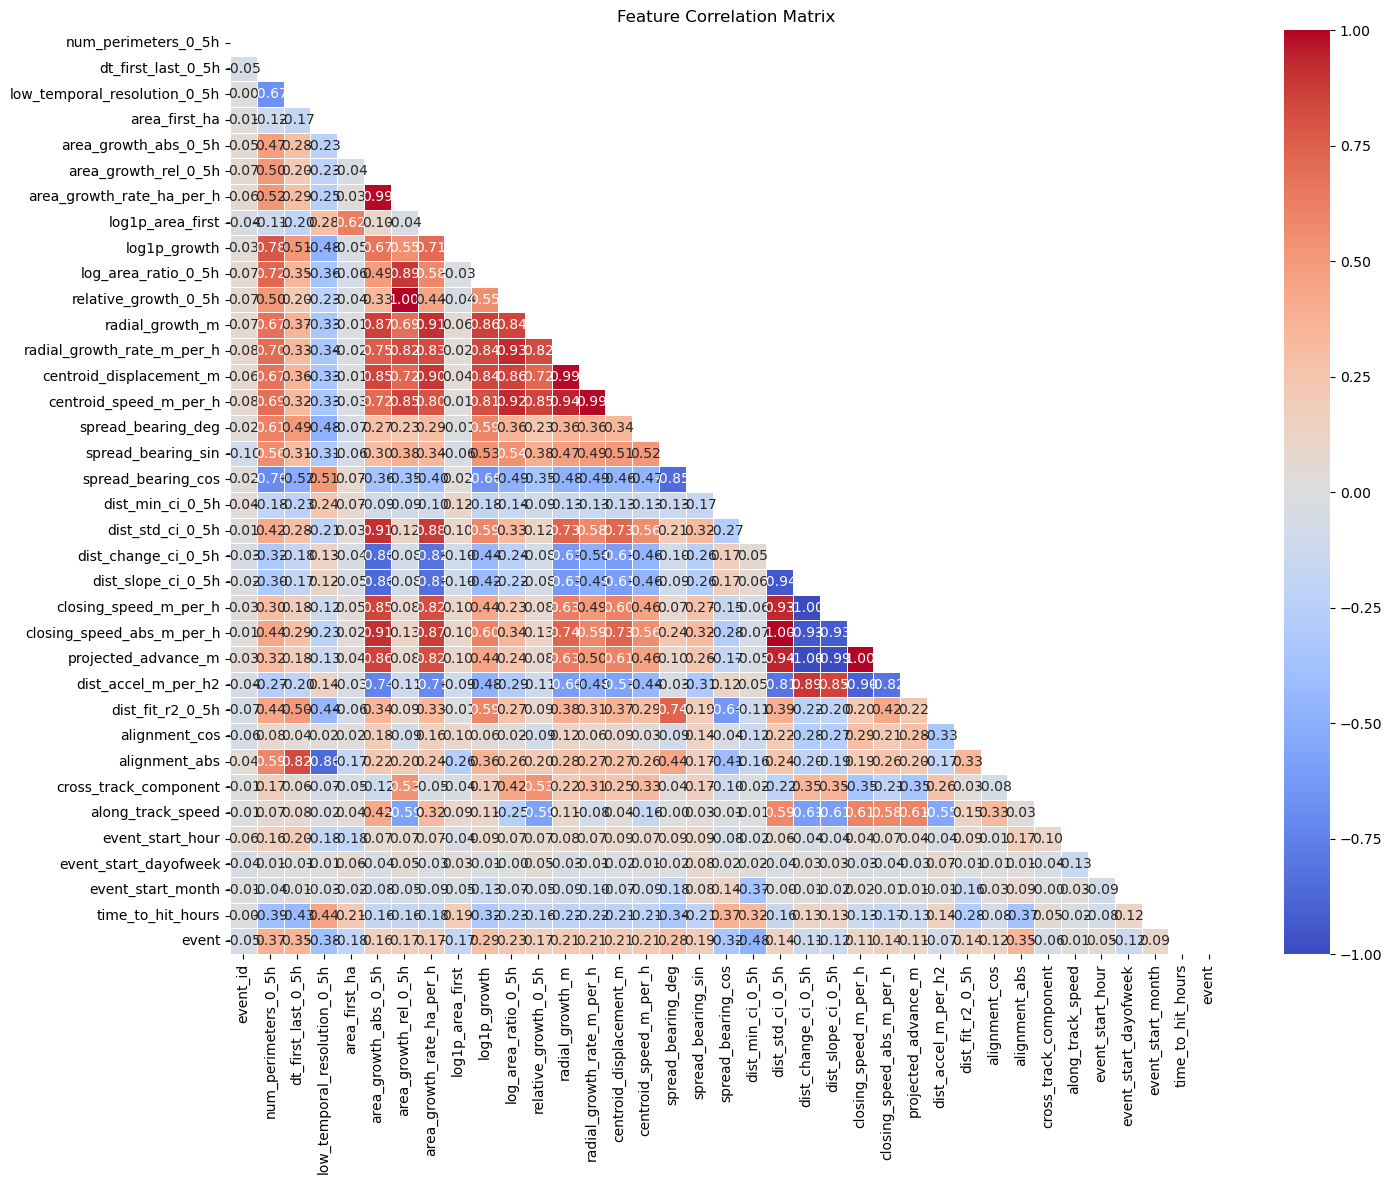

In [54]:
# Review correlation graphically
plt.figure(figsize=(16, 12))

# Create a mask to hide the upper triangle (it's a mirror of the lower)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,          
            fmt=".2f",           
            cmap='coolwarm',     # Red is positive, Blue is negative correlation
            vmin=-1, vmax=1, 
            center=0,
            linewidths=.5)

plt.title('Feature Correlation Matrix')
plt.show()

Recommendations:

    Log Transformation:\
        area_first_ha
        dist_min_ci_0_5h

    Robust Scaling(Interquartile Range):
        log_area_ratio_0_5h
        cross_track_component
        along_track_speed
        relative_growth_0_5h
        radial_growth_m
        radial_growth_rate_m_per_h
        centroid_displacement_m
        centroid_speed_m_per_h
        spread_bearing_deg
        spread_bearing_sin
        dist_std_ci_0_5h
        dist_change_ci_0_5h
        dist_slope_ci_0_5h
        closing_speed_m_per_h


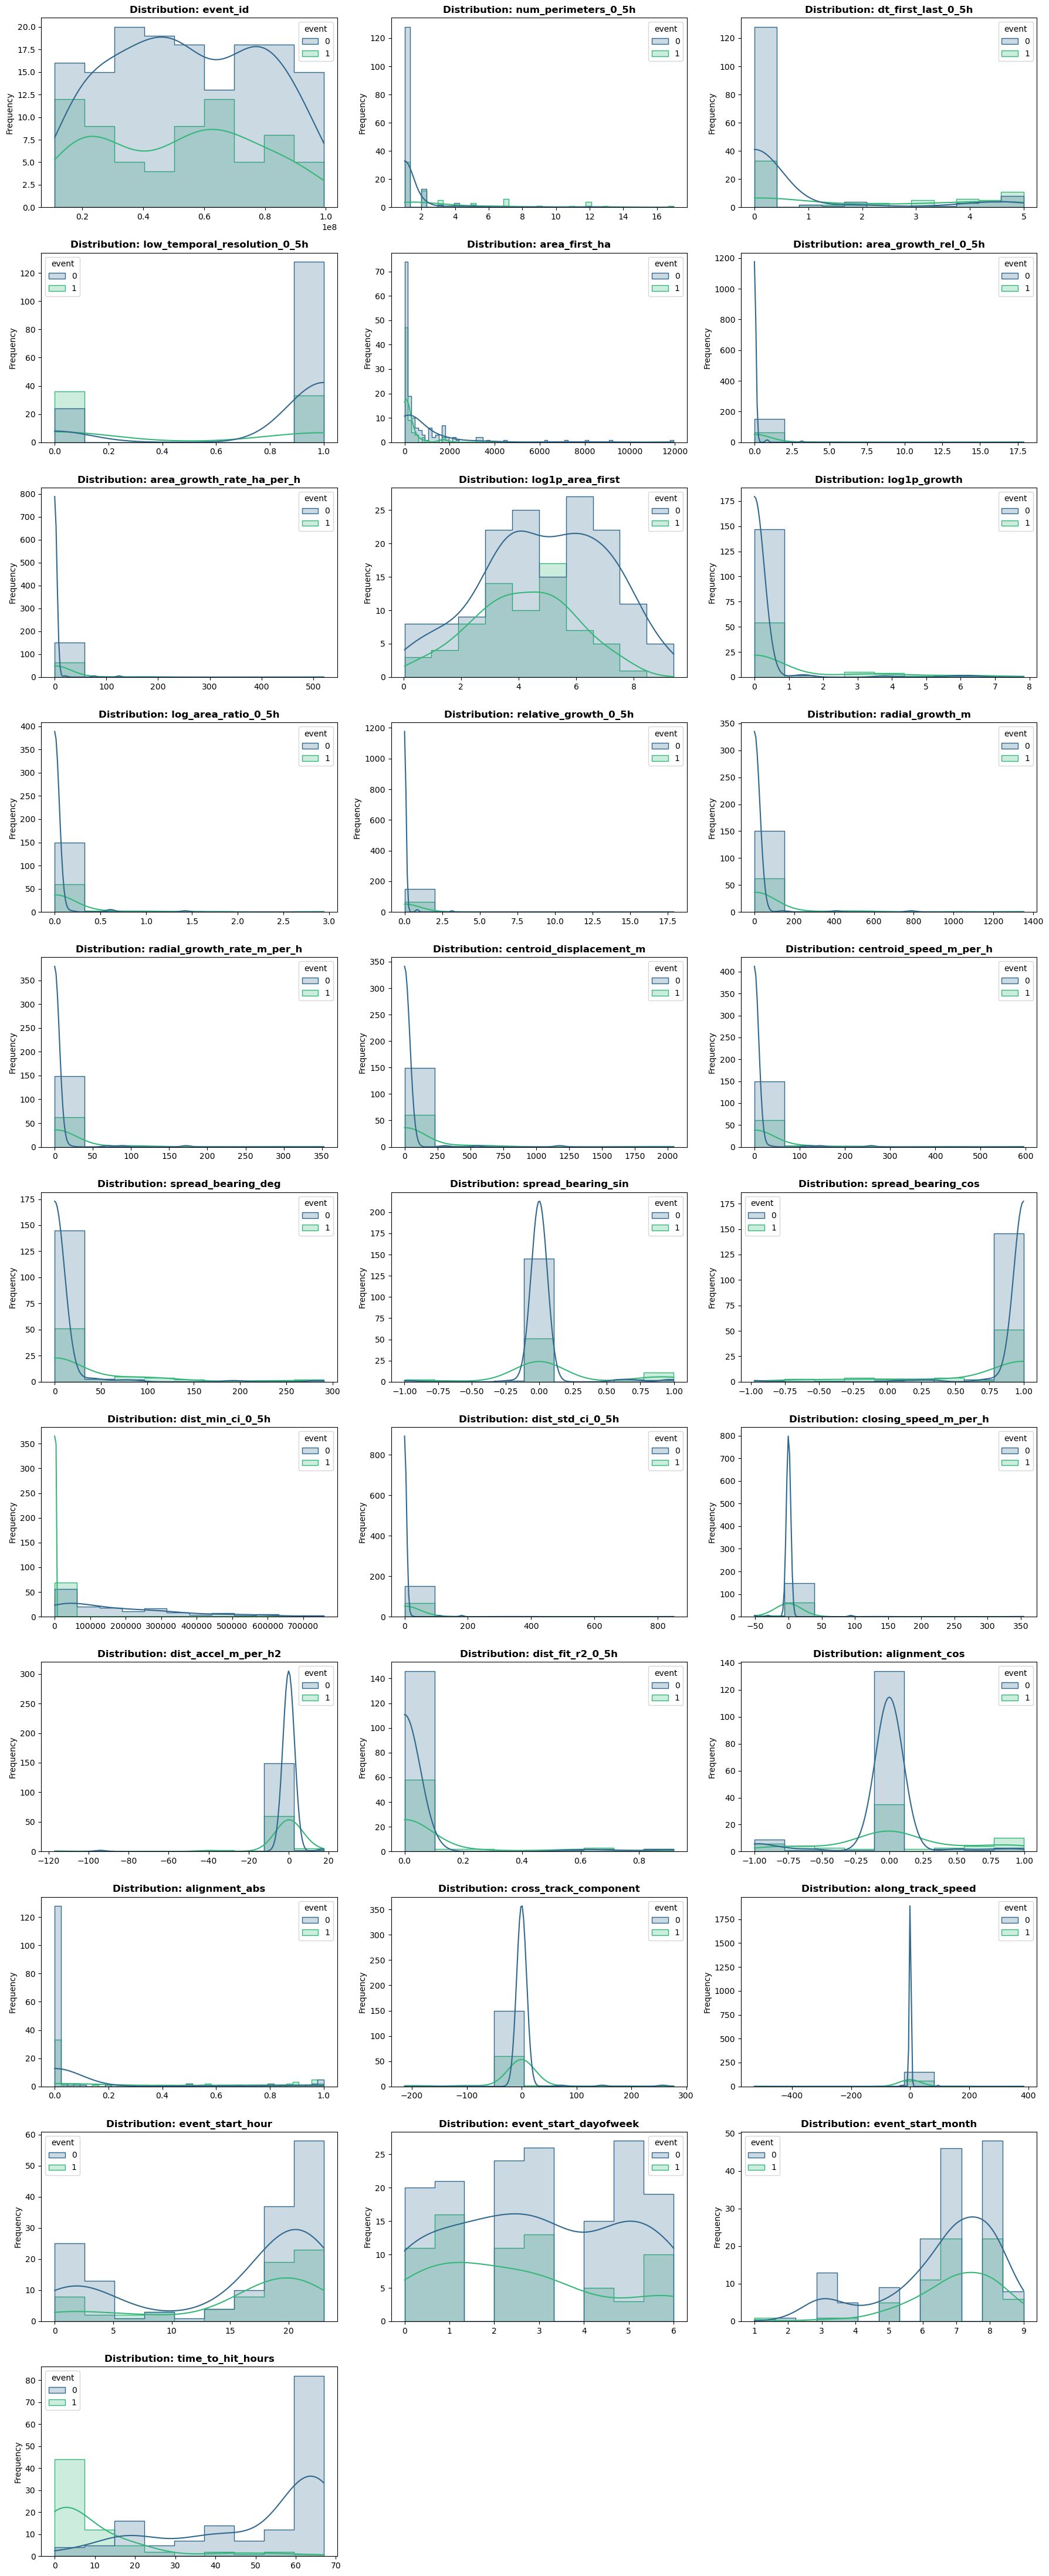

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

def plot_feature_distributions(df, target_col='event'):
    """
    Generates a grid of histograms with KDE for all numerical features,
    colored by the target class to visualize separability.
    """
    # Select only numerical columns (excluding the target)
    cols = df.select_dtypes(include=['number']).columns.tolist()
    if target_col in cols:
        cols.remove(target_col)
    
    # Configure the grid layout
    n_cols = 3
    n_rows = math.ceil(len(cols) / n_cols)
    
    # Create the figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten() # Flatten to iterate easily through the grid

    for i, col in enumerate(cols):
        sns.histplot(
            data=df, 
            x=col, 
            hue=target_col, 
            kde=True, 
            element="step", 
            palette="viridis", 
            ax=axes[i]
        )
        axes[i].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequency')
        
    # Remove empty subplots if the number of columns isn't a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# To execute:
plot_feature_distributions(df)

Most of the variables are skewed to the right or left and need to be standardized before doing any predictions. If left as they are they can break the logistic regression model.

Final Recommendations:
    Drop highly correlated columns to avoid redundancy and multicoliniality:
            dist_change_ci_0_5h
            projected_advance_m
            closing_speed_abs_m_per_h
            area_growth_abs_0_5h
            dist_slope_ci_0_5h
        Please note: The columns mentioned above have a correlation above 99%, but more columns can be selected that are above 90%, this will depend highly on the results in the prediction.

    Standardize features
        Apply log1p to extreme outliers (values are on corners) :
            area_first_ha
            radial_growth_m
            centroid_displacement_m
            dist_min_ci_0_5h
            closing_speed_m_per_h

        Apply RobustScaler where values are not on corners but there are differente ranges:
            num_perimeters_0_5h
            dt_first_last_0_5h
            area_growth_rate_ha_per_h
            centroid_speed_m_per_h
            radial_growth_rate_m_per_h
            dist_std_ci_0_5h
            along_track_speed
            cross_track_component

        Do not change the following since these are already standardized:
            low_temporal_resolution_0_5h
            spread_bearing_sin
            spread_bearing_cos
            alignment_cos
            alignment_abs
            event_start_hour
            event_start_dayofweek
            event_start_month
